# VAR Model Analysis of Turkish Macroeconomic Dynamics (2019–2025)

This notebook estimates a Vector Autoregression (VAR) model to analyze
the dynamic relationships between Consumer Confidence (TGE) and key
macroeconomic variables in Turkey.

Variables included in the model:

- TGE — Consumer Confidence Index
- USDTRY — Exchange Rate Change
- CPI — Inflation (log difference)
- IPI — Industrial Production Growth
- BIST — Stock Market Returns
- TLREF — Interest Rate Change
- UNEMPLOYMENT — Unemployment Rate Change

The dataset used in this model is the stationary transformation of the
original macroeconomic series constructed in previous notebooks.

Analysis steps include:

1. Loading the transformed dataset
2. Lag order selection
3. VAR model estimation
4. Granger causality analysis
5. Impulse response functions (IRF)
6. Forecast error variance decomposition (FEVD)

In [1]:
import pandas as pd

# model dataset yükle
df = pd.read_csv("../data/processed/macro_model_dataset_2019_2025.csv")

# tarih sütununu datetime yap
df["date"] = pd.to_datetime(df["date"])

# index olarak ayarla
df = df.set_index("date")

df.head()

,tge,usdtry,cpi,ipi,unemployment,bist,tlref
date,,,,,,,
2019-02-01,-0.016651,-0.020193,0.001606,0.011441,0.014599,0.004372,0.014336
2019-03-01,0.028898,0.033614,0.010231,0.029540,0.007220,-0.108480,-0.013997
2019-04-01,0.030494,0.052587,0.016789,-0.005597,-0.007220,0.017252,0.046339
2019-05-01,-0.081785,0.053244,0.009452,0.008297,-0.007273,-0.051902,0.017506
2019-06-01,0.038803,-0.040053,0.000266,-0.043801,0.000000,0.063044,-0.027796


Lag Selection

VAR modelinde en önemli şeylerden biri:

kaç gecikme (lag) kullanılacak

### Buna information criteria ile karar verilir.
En yaygın:

AIC
BIC
HQIC
FPE

In [2]:
from statsmodels.tsa.api import VAR

In [4]:
model = VAR(df)

lag_selection = model.select_order(maxlags=6)

print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -42.52     -42.30*   3.426e-19      -42.43
1      -43.98      -42.28   7.982e-20     -43.30*
2      -44.13      -40.94  7.053e-20*      -42.86
3      -43.99      -39.30   8.832e-20      -42.11
4      -43.81      -37.63   1.241e-19      -41.33
5      -43.70      -36.03   1.822e-19      -40.63
6     -44.23*      -35.06   1.705e-19      -40.56
-------------------------------------------------


c:\Users\LenovoTuncay\Documents\turkey_macro_var_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [5]:
var_model = model.fit(2)

print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 07, Mar, 2026
Time:                     16:02:27
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                   -41.1205
Nobs:                     81.0000    HQIC:                  -42.9791
Log likelihood:           1091.55    FPE:                6.40800e-20
AIC:                     -44.2244    Det(Omega_mle):     1.95083e-20
--------------------------------------------------------------------
Results for equation tge
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.005679         0.007916            0.717           0.473
L1.tge                 -0.145442         0.127166           -1.144           0.253
L1.usdtry              -0.255731         0.142485     

In [7]:
granger_test = var_model.test_causality(
    "tge",
    ["usdtry", "cpi", "ipi", "unemployment", "bist", "tlref"],
    kind="f"
)

print(granger_test.summary())

Granger causality F-test. H_0: ['usdtry', 'cpi', 'ipi', 'unemployment', 'bist', 'tlref'] do not Granger-cause tge. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         1.865          1.773   0.037 (12, 462)
-----------------------------------------------


H0: Makro değişkenler → TGE'yi Granger cause etmez
    p-value = 0.037
        p < 0.05 → H0 reddedilir
            Makro değişkenler → TGE üzerinde Granger nedenselliğe sahiptir.
            Kur, enflasyon, üretim, işsizlik, borsa ve faiz değişimleri
→ gelecekteki tüketici güveni değişimini açıklayabiliyor.

Tüketici güveni makro ekonomik gelişmelere tepki vermektedir.

Özellikle:

finansal piyasalar

döviz kuru

fiyat hareketleri

tüketici beklentilerini etkilemektedir.

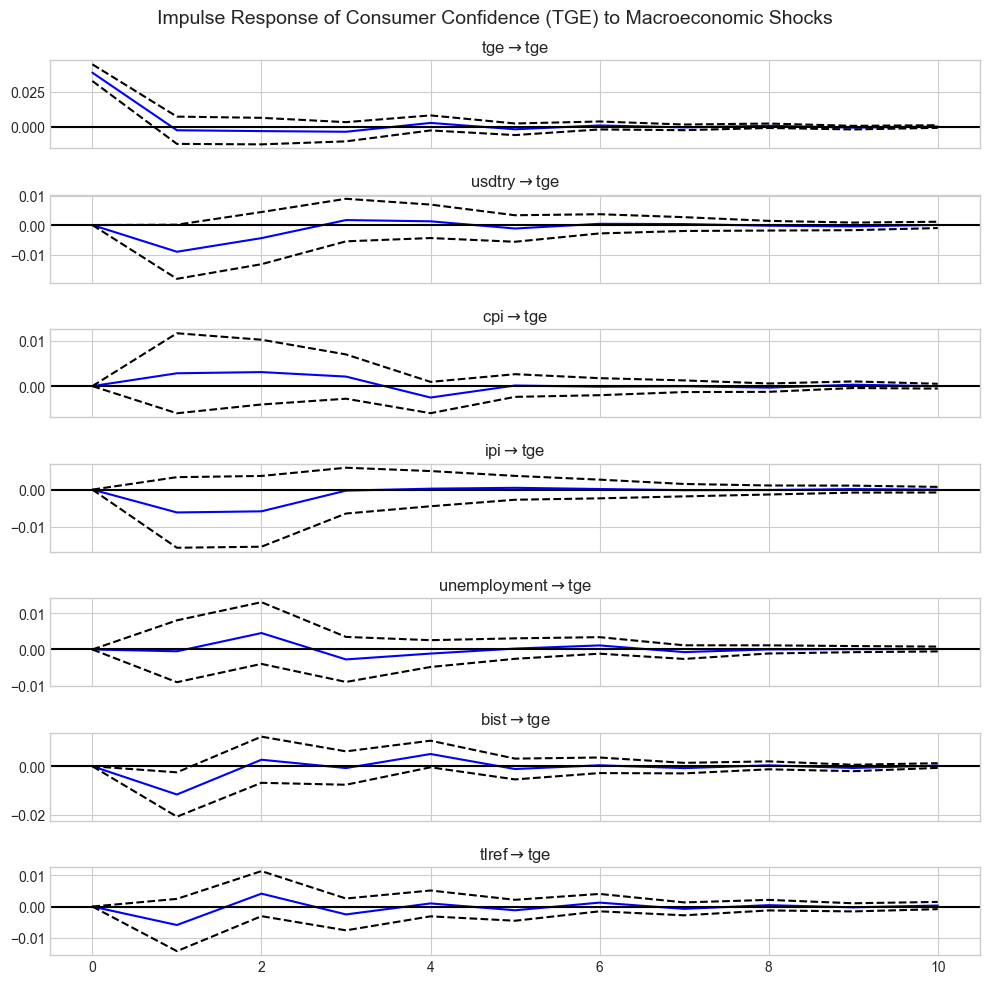

In [15]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# Impulse Response Analysis
irf = var_model.irf(10)

fig = irf.plot(response="tge", orth=True)

plt.suptitle(
    "Impulse Response of Consumer Confidence (TGE) to Macroeconomic Shocks",
    fontsize=14
)

plt.tight_layout()

plt.savefig("../assets/irf_consumer_confidence.png", dpi=300, bbox_inches="tight")

plt.show()

English

The impulse response analysis suggests that consumer confidence reacts mainly to exchange rate and financial shocks, while the effects of macroeconomic variables dissipate relatively quickly over time.

Türkçe

İtki-tepki analizi, tüketici güveninin özellikle döviz kuru ve finansal şoklara tepki verdiğini, ancak bu etkilerin zaman içinde hızlı şekilde sönümlendiğini göstermektedir.

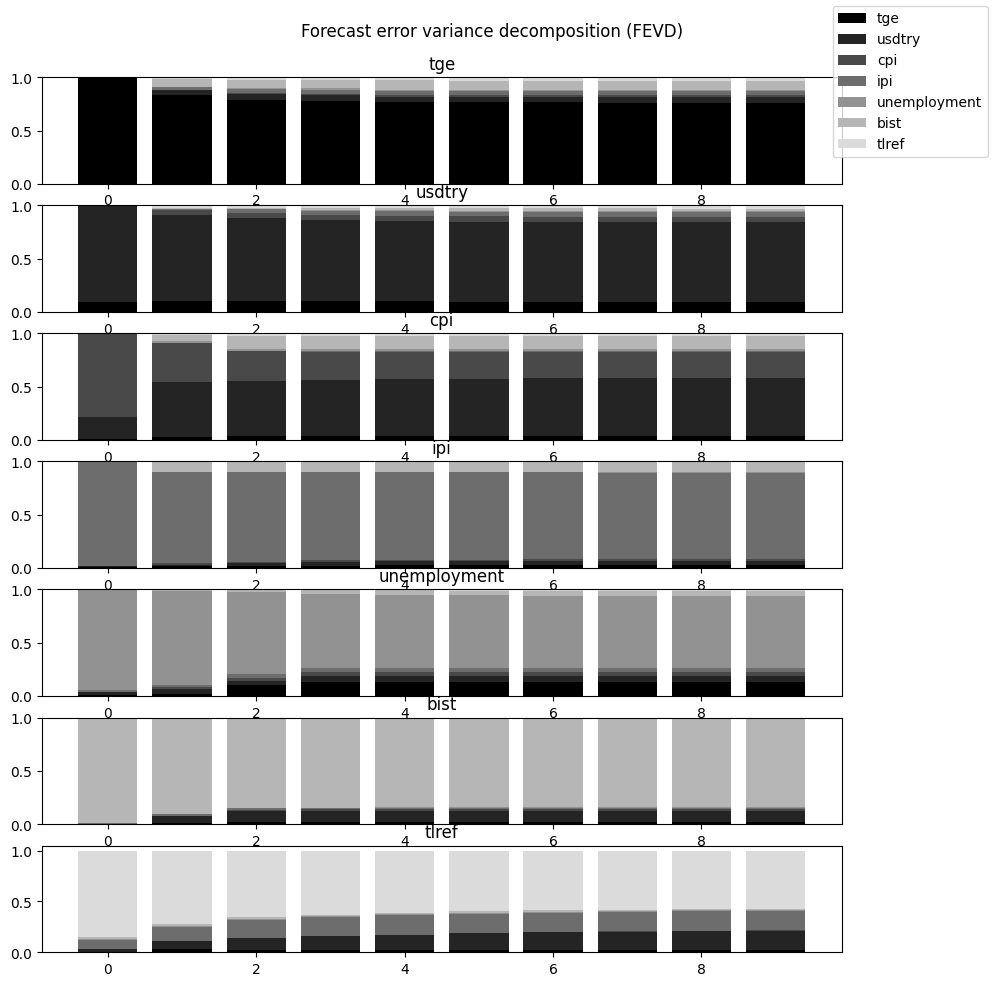

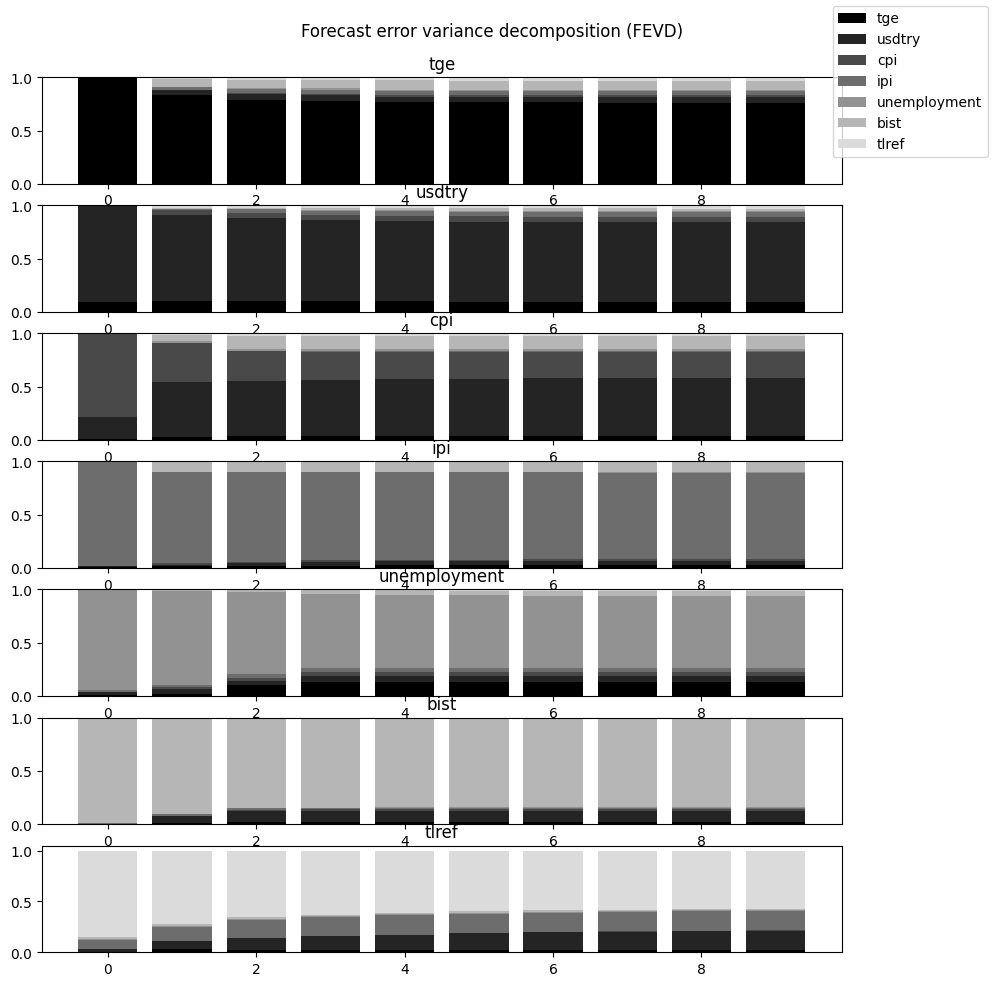

In [9]:
fevd = var_model.fevd(10)

fevd.plot()

Türkiye’de tüketici güveni finansal piyasalara daha hızlı tepki veriyor.

Bu çok mantıklı çünkü:

kur
borsa
faiz

gündelik beklentileri doğrudan etkiliyor.

